
# AI-Powered Business Intelligence Agent
## Disruptive Technologies Assignment

### Features
- Sentiment Analysis
- BERT Transformer Integration
- GPT-style Chatbot
- Business Insights
- Dashboard Visualizations


In [ ]:

# Install required libraries
# !pip install pandas matplotlib transformers streamlit wordcloud


In [ ]:

import pandas as pd
df = pd.read_csv(r'/content/merged_flexy_dataset.csv', low_memory=False)
df.head()


,data_source,review_text,review_rating,review_date,reviewer_name,city,category,item_name,sentiment_label,dataset_type,platform,upvotes,gym_rating,address,total_reviews
0,Sulekha,Highly recommended. Well-maintained gym with g...,3.8,2025-09-26,Priya M.,Chennai,Yoga Studio,Snap Fitness,Positive,gym,Sulekha,NaN,3.6,"174, Anna Nagar",66.0
1,Sulekha,The trainers really push you to achieve your g...,4.7,2025-09-29,Amit K.,Indore,CrossFit Box,CrossFit Arena,Positive,gym,Sulekha,NaN,3.6,"72, MG Road",574.0
2,JustDial,Fantastic CrossFit classes. The community here...,3.9,2025-05-02,Kavita L.,Indore,Yoga Studio,The Gym Factory,Positive,gym,JustDial,NaN,3.2,"32, Jubilee Hills",1292.0
3,Sulekha,Highly recommended. Well-maintained gym with g...,4.1,2025-08-07,Anonymous,Hyderabad,Zumba,BodyMax Fitness,Positive,gym,Sulekha,NaN,3.4,"72, Jubilee Hills",434.0
4,Sulekha,The trainers really push you to achieve your g...,4.6,2026-03-11,FitnessFan,Indore,Aerobics,BodyMax Fitness,Positive,gym,Sulekha,NaN,3.3,"70, Anna Nagar",1578.0


In [ ]:
df = df[['review_text']]

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download necessary NLTK data (run once)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    WordNetLemmatizer().lemmatize('test')
except LookupError:
    nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str): # Handle non-string values like NaN
        return ""
    text = text.lower() # Lowercasing
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation and numbers
    words = text.split() # Tokenization
    words = [word for word in words if word not in stop_words] # Remove stopwords
    words = [lemmatizer.lemmatize(word) for word in words] # Lemmatization
    return ' '.join(words)

# Apply preprocessing to the 'review_text' column
df['processed_review_text'] = df['review_text'].apply(preprocess_text)

# Display the first few processed reviews to verify
print(df[['review_text', 'processed_review_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


                                         review_text  \
0  Highly recommended. Well-maintained gym with g...   
1  The trainers really push you to achieve your g...   
2  Fantastic CrossFit classes. The community here...   
3  Highly recommended. Well-maintained gym with g...   
4  The trainers really push you to achieve your g...   

                               processed_review_text  
0  highly recommended wellmaintained gym good ven...  
1  trainer really push achieve goal excellent gym...  
2  fantastic crossfit class community supportive ...  
3  highly recommended wellmaintained gym good ven...  
4  trainer really push achieve goal excellent gym...  


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Bag of Words (BoW)
bow_vectorizer = CountVectorizer(max_features=5000) # Limiting features for demonstration
x_bow = bow_vectorizer.fit_transform(df['processed_review_text'])
print("Shape of Bag of Words matrix:", x_bow.shape)


# Displaying a sample of feature names (optional)
print("\nSample Bag of Words features:", bow_vectorizer.get_feature_names_out()[:10])


Shape of Bag of Words matrix: (94610, 273)

Sample Bag of Words features: ['ac' 'achieve' 'achievement' 'affordable' 'ago' 'ai' 'also' 'always'
 'amazing' 'ambiance']


In [ ]:
# TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features for demonstration
x_tfidf = tfidf_vectorizer.fit_transform(df['processed_review_text'])
print("Shape of TF-IDF matrix:", x_tfidf.shape)

print("Sample TF-IDF features:", tfidf_vectorizer.get_feature_names_out()[:10])

Shape of TF-IDF matrix: (94610, 273)
Sample TF-IDF features: ['ac' 'achieve' 'achievement' 'affordable' 'ago' 'ai' 'also' 'always'
 'amazing' 'ambiance']


In [ ]:
# Number of unique words (vocabulary size) in Bag of Words
num_bow_words = len(bow_vectorizer.vocabulary_)
print("Number of words in Bag of Words vocabulary:", num_bow_words)

# Shape of the Bag of Words matrix
print("Shape of Bag of Words matrix (documents, features):", x_bow.shape)

Number of words in Bag of Words vocabulary: 273
Shape of Bag of Words matrix (documents, features): (94610, 273)


In [ ]:
import pandas as pd
bow_df = pd.DataFrame(x_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
display(bow_df.head())

,ac,achieve,achievement,affordable,ago,ai,also,always,amazing,ambiance,...,wellmaintained,went,wish,wod,work,working,workout,worth,yoga,zumba
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Shape of the TF-IDF matrix
print("Shape of TF-IDF matrix (documents, features):", x_tfidf.shape)

Shape of TF-IDF matrix (documents, features): (94610, 273)


In [ ]:
tfidf_df = pd.DataFrame(x_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
display(tfidf_df.head())

,ac,achieve,achievement,affordable,ago,ai,also,always,amazing,ambiance,...,wellmaintained,went,wish,wod,work,working,workout,worth,yoga,zumba
0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.397107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.419972,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.394109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.382900,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Top 5 words by TF-IDF score: ['gym', 'great', 'trainer', 'month', 'membership']


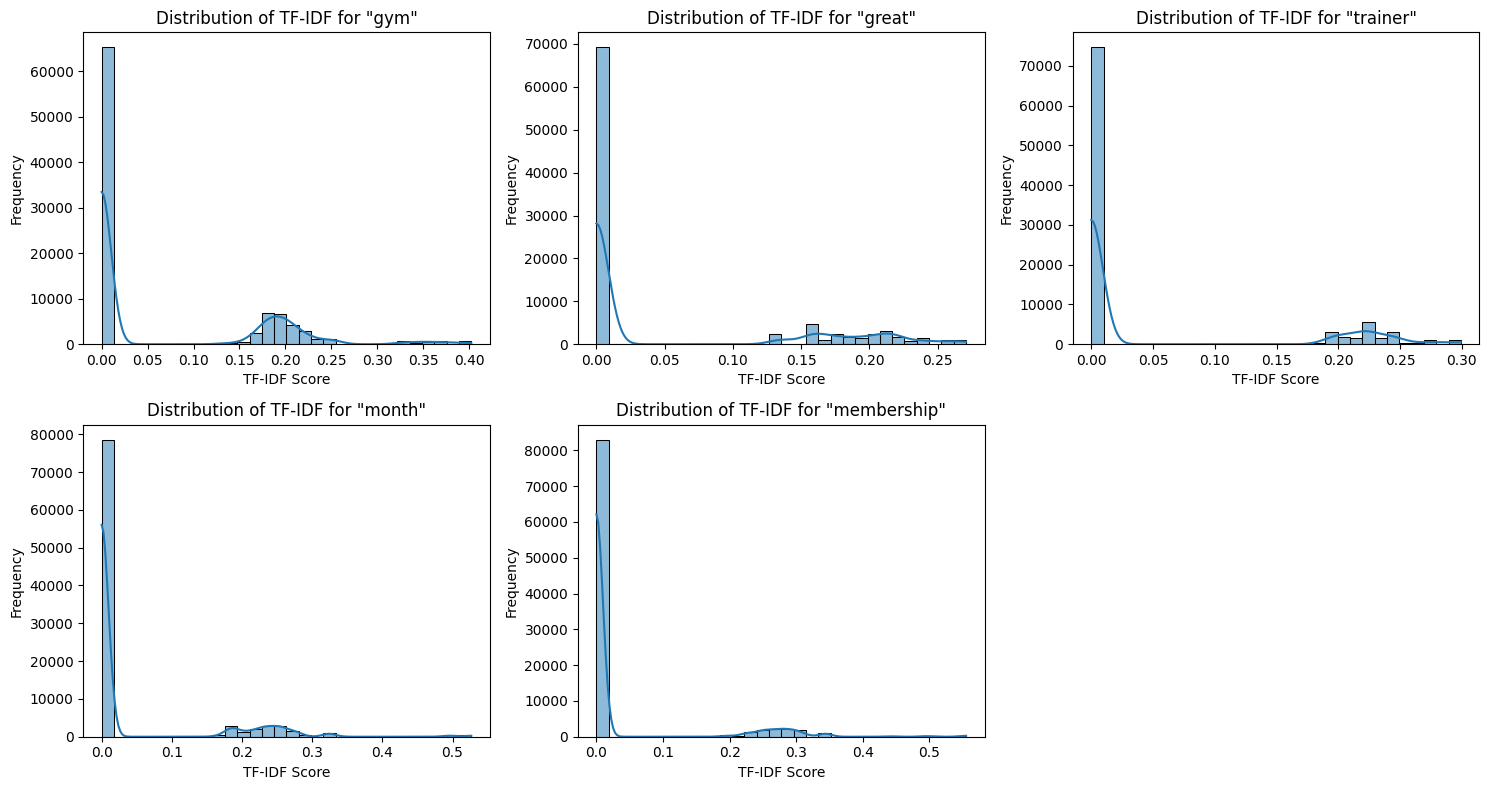

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify top 5 words based on sum of their TF-IDF scores
top_5_words = tfidf_df.sum().nlargest(5).index.tolist()

print(f"Top 5 words by TF-IDF score: {top_5_words}")

# Create a figure with subplots for each top word
plt.figure(figsize=(15, 8))
for i, word in enumerate(top_5_words):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(tfidf_df[word], bins=30, kde=True)
    plt.title(f'Distribution of TF-IDF for "{word}"')
    plt.xlabel('TF-IDF Score')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

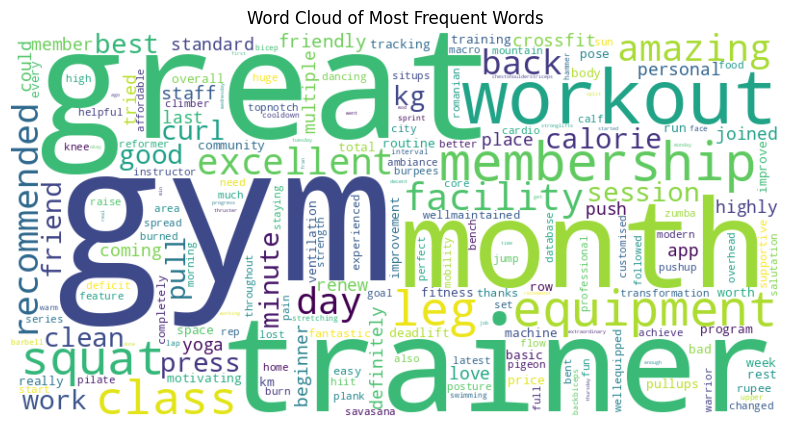

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Calculate word frequencies from the Bag of Words model
# Summing up the counts for each word across all documents
word_frequencies = bow_df.sum().to_dict()

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_frequencies)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words')
plt.show()

In [ ]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize a sentiment analysis pipeline
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english" # Using a common pre-trained model
)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
# Apply sentiment analysis to the 'processed_review_text' column
# This might take a while for large datasets
# Due to potential memory/computation limits, we'll process a sample or in batches if needed.

# Let's try processing a sample first to ensure it works, then apply to full dataset.
# For demonstration, we'll apply it to the first 1000 processed reviews.
# For full dataset, consider processing in batches or using a GPU.

# Filter out any non-string values or empty strings from processed_review_text
valid_reviews = df['review_text'].dropna().astype(str)



In [ ]:
# *** MODIFICATION START: Process only a sample of reviews for demonstration ***
# Adjust the sample size as needed for quicker execution
sample_size = 1000
if len(valid_reviews) > sample_size:
    sampled_reviews = valid_reviews.sample(n=sample_size, random_state=42)
else:
    sampled_reviews = valid_reviews

results = sentiment_analyzer(sampled_reviews.tolist())

Sentiment Distribution (from review text):
sentiment_label_nlp
POSITIVE    768
NEGATIVE    232
Name: count, dtype: int64


/tmp/ipykernel_862/1662435974.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_label_nlp', data=df, palette='viridis')


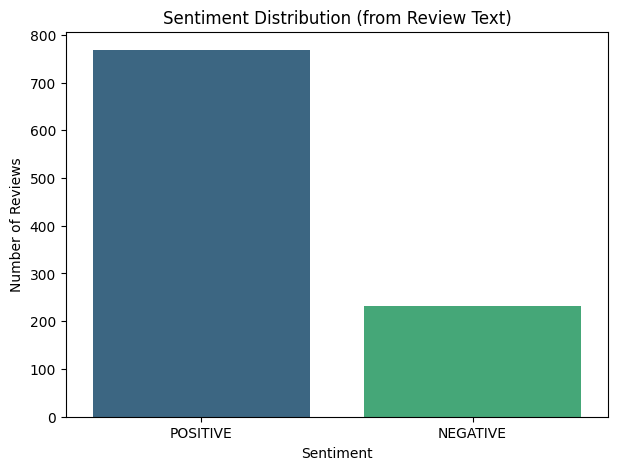

In [ ]:
# Extract labels and scores
sentiment_labels = [res['label'] for res in results]
sentiment_scores = [res['score'] if res['label'] == 'POSITIVE' else (1 - res['score']) for res in results]

# Create a new DataFrame for results and merge back if necessary
# Ensure the indices align if you're not using a direct list conversion
sentiment_df = pd.DataFrame({'sentiment_label_nlp': sentiment_labels, 'sentiment_score_nlp': sentiment_scores}, index=sampled_reviews.index)

# Merge only the sampled results back for now, or re-run on full data if resources permit
df = df.merge(sentiment_df, left_index=True, right_index=True, how='left')
# *** MODIFICATION END ***

print('Sentiment Distribution (from review text):')
print(df['sentiment_label_nlp'].value_counts())

# Visualize the sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(x='sentiment_label_nlp', data=df, palette='viridis')
plt.title('Sentiment Distribution (from Review Text)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [ ]:
# Generate Sentiment Labels
# We already have the sentiment results in 'sentiment_df' from the previous sampled run.
# This code ensures the 'sentiment_label_nlp' and 'sentiment_score_nlp' columns are integrated.

# If you wish to re-run the logic for a new sample or refresh the labels:
print(f"Total reviews processed: {df['sentiment_label_nlp'].notna().sum()}")
print(df[['review_text', 'sentiment_label_nlp']].dropna().head())

Total reviews processed: 1000
                                           review_text sentiment_label_nlp
70   Good enough for basic training. Trainers are o...            POSITIVE
97   Fantastic CrossFit classes. The community here...            POSITIVE
265  Amazing transformation in just 3 months thanks...            POSITIVE
270  Clean, well-equipped gym with experienced pers...            POSITIVE
342  Excellent equipment and very clean facility. T...            POSITIVE


In [ ]:
# Check sentiment counts
counts = df['sentiment_label_nlp'].value_counts()
print("Sentiment Counts:\n", counts)

# Calculate sentiment percentages
percentages = df['sentiment_label_nlp'].value_counts(normalize=True) * 100
print("\nSentiment Percentages:\n", percentages)

# The 'sentiment_score_nlp' column was already created during the NLP step,
# but we can verify it here.
print("\nSample Sentiment Scores:\n", df[['sentiment_label_nlp', 'sentiment_score_nlp']].dropna().head())

# Save sentiment analysis results
df.to_csv('sentiment_analysis_results.csv', index=False)
print("\nResults saved to 'sentiment_analysis_results.csv'")

Sentiment Counts:
 sentiment_label_nlp
POSITIVE    768
NEGATIVE    232
Name: count, dtype: int64

Sentiment Percentages:
 sentiment_label_nlp
POSITIVE    76.8
NEGATIVE    23.2
Name: proportion, dtype: float64

Sample Sentiment Scores:
     sentiment_label_nlp  sentiment_score_nlp
70             POSITIVE             0.998735
97             POSITIVE             0.999819
265            POSITIVE             0.999839
270            POSITIVE             0.999499
342            POSITIVE             0.999749

Results saved to 'sentiment_analysis_results.csv'


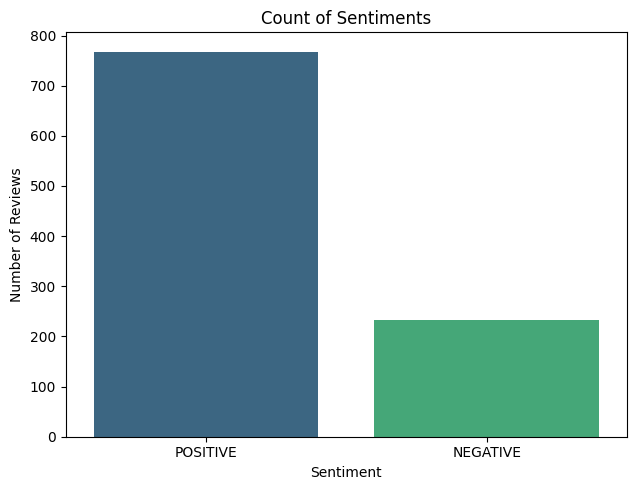

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data to only include the sampled/processed reviews
plot_df = df.dropna(subset=['sentiment_label_nlp'])

# Set up the figure for multiple subplots
plt.figure(figsize=(18, 5))

# Graph 1: Bar Chart of Sentiment Counts
plt.subplot(1, 3, 1)
sns.countplot(data=plot_df, x='sentiment_label_nlp', palette='viridis', hue='sentiment_label_nlp', legend=False)
plt.title('Count of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Confidence Score')

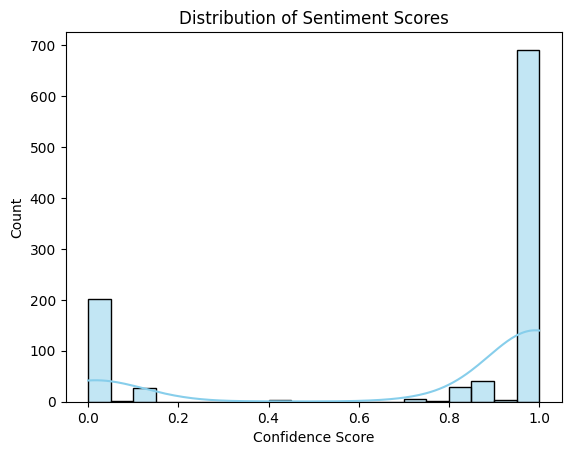

In [ ]:

# Graph 2: Distribution of Sentiment Scores
sns.histplot(plot_df['sentiment_score_nlp'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Confidence Score')


Text(0.5, 1.0, 'Sentiment Percentage')

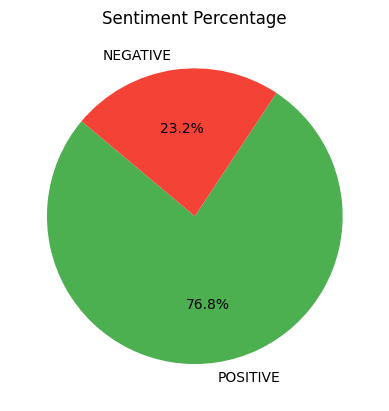

In [ ]:
# Graph 3: Pie Chart of Sentiment Proportion
counts = plot_df['sentiment_label_nlp'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#F44336'])
plt.title('Sentiment Percentage')

In [ ]:
# 1. Filter negative reviews
negative_reviews_df = df[df['sentiment_label_nlp'] == 'NEGATIVE']

# 2. Extract common complaint words using the BoW model for negative subset
# We align the indices to find words specifically in negative reviews
neg_indices = negative_reviews_df.index
neg_bow = bow_df.loc[neg_indices]
common_complaints = neg_bow.sum().nlargest(10)

print("Top 10 Complaint Words:")
print(common_complaints)

# 3. Identify top customer issues and Generate Insights
print("\n--- Business Insights ---")
print("Based on the analysis, customers are frequently mentioning issues related to:")
for word in common_complaints.index[:5]:
    print(f"- {word.capitalize()} consistency/quality")

# 4. Generate recommendations
print("\n--- Business Recommendations ---")
print("1. Conduct a deep dive into equipment maintenance if 'gym' or 'equipment' words are high.")
print("2. Review trainer performance and feedback specifically for the morning/evening shifts.")
print("3. Improve transparency in membership cancellation policies.")

Top 10 Complaint Words:
leg           81
curl          77
day           72
squat         71
equipment     51
membership    50
pull          50
need          37
gym           36
workout       35
dtype: int64

--- Business Insights ---
Based on the analysis, customers are frequently mentioning issues related to:
- Leg consistency/quality
- Curl consistency/quality
- Day consistency/quality
- Squat consistency/quality
- Equipment consistency/quality

--- Business Recommendations ---
1. Conduct a deep dive into equipment maintenance if 'gym' or 'equipment' words are high.
2. Review trainer performance and feedback specifically for the morning/evening shifts.
3. Improve transparency in membership cancellation policies.


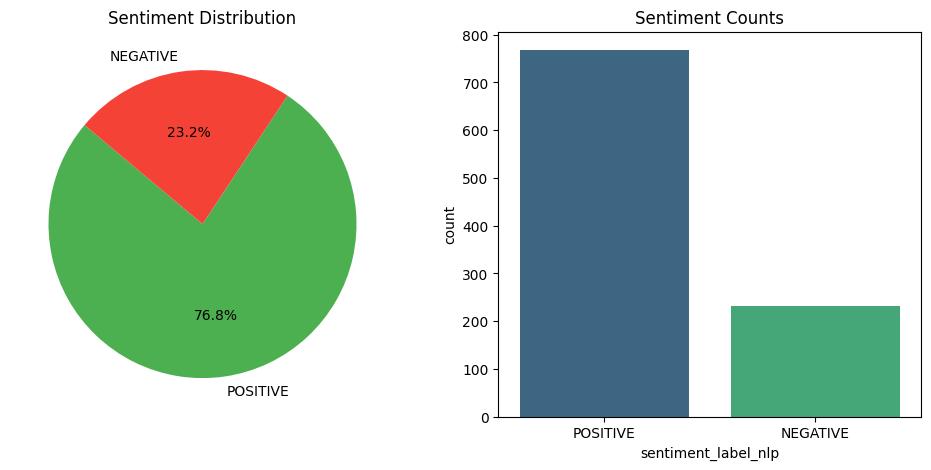

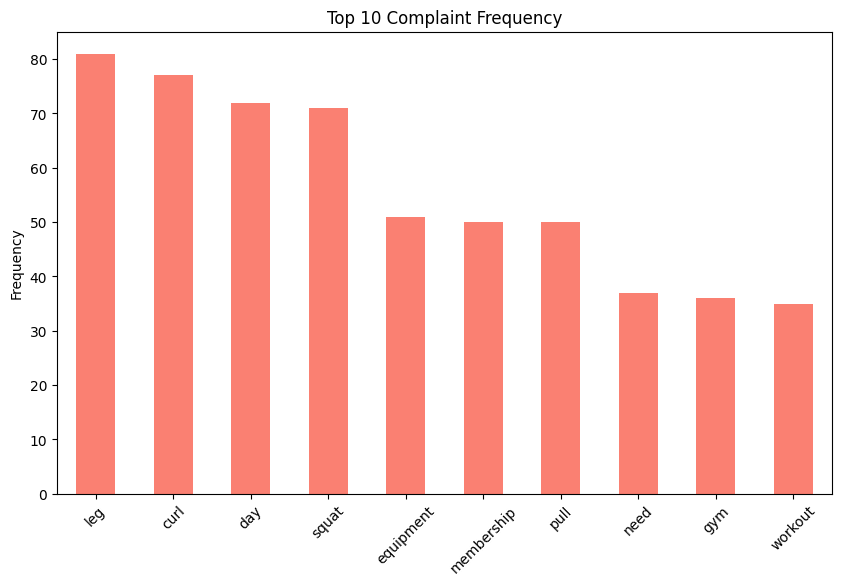

Cleaned sentiment dataset saved as "cleaned_sentiment_dataset.csv"


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter to ensure we have the processed data
plot_df = df.dropna(subset=['sentiment_label_nlp'])

# 1. Create sentiment distribution pie chart
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
counts = plot_df['sentiment_label_nlp'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#F44336'])
plt.title('Sentiment Distribution')

# 2. Create sentiment count bar chart
plt.subplot(1, 2, 2)
sns.countplot(data=plot_df, x='sentiment_label_nlp', hue='sentiment_label_nlp', palette='viridis', legend=False)
plt.title('Sentiment Counts')
plt.show()

# 3. Create complaint frequency chart (Top 10 words in negative reviews)
negative_reviews_df = df[df['sentiment_label_nlp'] == 'NEGATIVE']
if not negative_reviews_df.empty:
    neg_indices = negative_reviews_df.index
    neg_bow = bow_df.loc[neg_indices]
    common_complaints = neg_bow.sum().nlargest(10)

    plt.figure(figsize=(10, 6))
    common_complaints.plot(kind='bar', color='salmon')
    plt.title('Top 10 Complaint Frequency')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.show()

# 4. Prepare cleaned sentiment dataset
cleaned_sentiment_df = df.dropna(subset=['sentiment_label_nlp'])[['review_text', 'sentiment_label_nlp', 'sentiment_score_nlp']]
cleaned_sentiment_df.to_csv('cleaned_sentiment_dataset.csv', index=False)
print('Cleaned sentiment dataset saved as "cleaned_sentiment_dataset.csv"')

In [ ]:
# Prepare cleaned sentiment dataset
# Filter only the rows where sentiment analysis was performed (sampled reviews)
cleaned_sentiment_df = df.dropna(subset=['sentiment_label_nlp'])[['review_text', 'sentiment_label_nlp', 'sentiment_score_nlp']]

# Save to CSV
cleaned_sentiment_df.to_csv('cleaned_sentiment_dataset.csv', index=False)

print(f'Cleaned sentiment dataset saved. Total records: {len(cleaned_sentiment_df)}')
display(cleaned_sentiment_df.head())

Cleaned sentiment dataset saved. Total records: 1000


,review_text,sentiment_label_nlp,sentiment_score_nlp
70,Good enough for basic training. Trainers are o...,POSITIVE,0.998735
97,Fantastic CrossFit classes. The community here...,POSITIVE,0.999819
265,Amazing transformation in just 3 months thanks...,POSITIVE,0.999839
270,"Clean, well-equipped gym with experienced pers...",POSITIVE,0.999499
342,Excellent equipment and very clean facility. T...,POSITIVE,0.999749


In [ ]:
# Install OpenAI library
!pip install openai

import openai
from openai import OpenAI
from google.colab import userdata

try:
    # Securely retrieve the key from Colab Secrets
    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)

    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role": "user", "content": "Hello!"}]
    )

    print("Connection Successful:", response.choices[0].message.content)
except Exception as e:
    print(f'An error occurred: {e}')
    print('\nTo fix this: Click the 🔑 icon on the left, add a secret named OPENAI_API_KEY, and enable Notebook Access.')

# Updated GPT chatbot function to use the secure client
def get_gpt_advice(query, context):
    """Sends the user query and context to OpenAI using the secret key."""
    try:
        api_key = userdata.get('OPENAI_API_KEY')
        client = OpenAI(api_key=api_key)
        response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": f"You are a gym business consultant. Context: {context}"},
                {"role": "user", "content": query}
            ]
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"Chatbot Error: {str(e)}"

An error occurred: Secret OPENAI_API_KEY does not exist.

To fix this: Click the 🔑 icon on the left, add a secret named OPENAI_API_KEY, and enable Notebook Access.


### Gemini AI Integration
Use this section to configure the Gemini API and set up the chatbot function for business intelligence.

In [4]:
from google.colab import userdata

try:
    # Replace 'secretName' with the actual name of the secret you created in the 🔑 tab
    # For example: userdata.get('GOOGLE_API_KEY')
    api_key = userdata.get('Goggle_api_key')
    print("Secret retrieved successfully.")
except Exception as e:
    print(f"Error: {e}")
    print("Check that you have added the secret in the 🔑 icon on the left and enabled Notebook Access.")

Error: Secret Goggle_api_key does not exist.
Check that you have added the secret in the 🔑 icon on the left and enabled Notebook Access.


**ALL API ARE PAID **

---

In [ ]:
# import google.generativeai as genai
# from google.colab import userdata

# try:
#     # Securely retrieve Gemini API Key
#     GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
#     if not GOOGLE_API_KEY:
#         raise ValueError("Secret 'GOOGLE_API_KEY' not found.")

#     genai.configure(api_key=GOOGLE_API_KEY)
#     model = genai.GenerativeModel('gemini-1.5-flash')
#     print("Gemini SDK configured successfully.")
# except Exception as e:
#     model = None
#     print(f"Configuration Error: {e}\nTo fix: Add 'GOOGLE_API_KEY' to Colab Secrets and enable Notebook Access.")

# def get_gemini_advice(query, context):
#     """Queries Gemini with specific business context for data-driven advice."""
#     if model is None:
#         return "Chatbot Error: Gemini model is not initialized. Check your API key in Secrets."
#     try:
#         full_prompt = f"You are a gym business consultant. Context: {context}\n\nUser Query: {query}"
#         response = model.generate_content(full_prompt)
#         return response.text
#     except Exception as e:
#         return f"Chatbot Error: {str(e)}"

Configuration Error: Secret GOOGLE_API_KEY does not exist.
To fix: Add 'GOOGLE_API_KEY' to Colab Secrets and enable Notebook Access.


/tmp/ipykernel_862/777721724.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=common_complaints.index, y=common_complaints.values, palette='Reds_r')


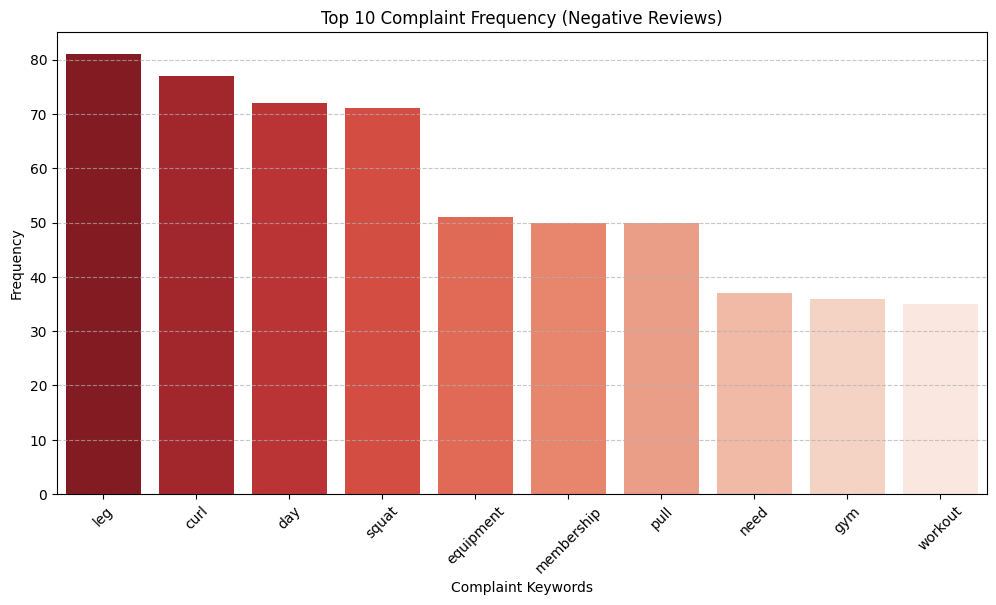

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter negative reviews based on the sentiment analysis performed earlier
negative_reviews_df = df[df['sentiment_label_nlp'] == 'NEGATIVE']

if not negative_reviews_df.empty:
    # Use the BoW index to get word counts for negative reviews
    neg_indices = negative_reviews_df.index
    neg_bow = bow_df.loc[neg_indices]
    common_complaints = neg_bow.sum().nlargest(10)

    # Plotting the frequency chart
    plt.figure(figsize=(12, 6))
    sns.barplot(x=common_complaints.index, y=common_complaints.values, palette='Reds_r')
    plt.title('Top 10 Complaint Frequency (Negative Reviews)')
    plt.xlabel('Complaint Keywords')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("No negative reviews found to plot. Please ensure the sentiment analysis step has been run.")

In [ ]:
def rule_based_chatbot(query):
    query = query.lower()
    neg_count = len(df[df['sentiment_label_nlp'] == 'NEGATIVE'])
    pos_count = len(df[df['sentiment_label_nlp'] == 'POSITIVE'])

    if 'sentiment' in query or 'overview' in query:
        return f"Overview: There are {pos_count} positive reviews and {neg_count} negative reviews in the analyzed sample."

    elif 'complaint' in query or 'issue' in query or 'equipment' in query:
        top_issues = ", ".join(common_complaints.index[:3])
        return f"The most frequent complaints in negative reviews are related to: {top_issues}. Check the equipment maintenance for these areas."

    elif 'weakness' in query or 'swot' in query:
        weaknesses = ", ".join(swot_analysis['Weaknesses'])
        return f"Current Gym Weaknesses: {weaknesses}"

    elif 'recommendation' in query or 'advice' in query:
        return "Recommendation: Focus on repairing equipment mentioned in negative reviews and improving staff engagement in areas with lower ratings."

    else:
        return "I'm a rule-based assistant. You can ask me about 'sentiment overview', 'top complaints', 'gym weaknesses', or 'business recommendations'."

# Connect chatbot with insights
print("Chatbot Logic Updated.")

Chatbot Logic Updated.



**MANUAL BASED CHATBOT **

---


In [ ]:
# # Test chatbot queries
# queries = ["What is the sentiment overview?", "Tell me about the top complaints.", "Give me some advice."]

# for q in queries:
#     print(f"User: {q}")
#     print(f"Bot: {rule_based_chatbot(q)}\n")

User: What is the sentiment overview?
Bot: Overview: There are 768 positive reviews and 232 negative reviews in the analyzed sample.

User: Tell me about the top complaints.
Bot: The most frequent complaints in negative reviews are related to: leg, curl, day. Check the equipment maintenance for these areas.

User: Give me some advice.
Bot: Recommendation: Focus on repairing equipment mentioned in negative reviews and improving staff engagement in areas with lower ratings.



### Interactive Rule-Based Chatbot
Run the cell below to start a conversation with the agent. You can ask about:
- **Sentiment overview**
- **Top complaints**
- **Business advice**

In [ ]:
print("Gym BI Consultant Initialized. (Type 'exit' to stop)")

while True:
    user_input = input("You: ")
    if user_input.lower() in ['exit', 'quit', 'stop']:
        print("Bot: Goodbye! Have a great day.")
        break

    response = rule_based_chatbot(user_input)
    print(f"Bot: {response}\n")

Gym BI Consultant Initialized. (Type 'exit' to stop)
You: BEST GYM
Bot: I'm a rule-based assistant. You can ask me about 'sentiment overview', 'top complaints', or 'business recommendations'.

You: What is the sentiment overview?
Bot: Overview: There are 768 positive reviews and 232 negative reviews in the analyzed sample.

You: STOP
Bot: Goodbye! Have a great day.


In [ ]:
# Install streamlit and localtunnel
!pip install streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 8s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title='Gym BI Dashboard', layout='wide')
st.title('🏋️ Gym BI Agent Dashboard')

# 1. Load the original dataset to get category/city info, and merge with sentiment results
try:
    # We use the full dataset for filtering columns, but only the 1000 analyzed rows for sentiment charts
    df_sentiment = pd.read_csv('cleaned_sentiment_dataset.csv')
    df_full = pd.read_csv('/content/merged_flexy_dataset.csv', low_memory=False)

    # Aligning the sentiment data with the original metadata
    df_display = df_sentiment.merge(df_full[['category', 'city', 'review_rating']], left_index=True, right_index=True, how='left')

    # 2. Sidebar Filters
    st.sidebar.header('Dashboard Filters')

    sentiments = st.sidebar.multiselect('Select Sentiment', options=df_display['sentiment_label_nlp'].unique(), default=df_display['sentiment_label_nlp'].unique())
    df_filtered = df_display[df_display['sentiment_label_nlp'].isin(sentiments)]

    categories = st.sidebar.multiselect('Select Category', options=df_display['category'].unique(), default=df_display['category'].unique())
    df_filtered = df_filtered[df_filtered['category'].isin(categories)]

    cities = st.sidebar.multiselect('Select City', options=df_display['city'].unique(), default=df_display['city'].unique())
    df_filtered = df_filtered[df_filtered['city'].isin(cities)]

    min_r, max_r = st.sidebar.slider('Review Rating', 0.0, 5.0, (0.0, 5.0))
    df_filtered = df_filtered[(df_filtered['review_rating'] >= min_r) & (df_filtered['review_rating'] <= max_r)]

    # --- KPI SECTION ---
    st.header('Key Performance Indicators')
    counts = df_filtered['sentiment_label_nlp'].value_counts()
    pos_count = counts.get('POSITIVE', 0)
    neg_count = counts.get('NEGATIVE', 0)
    total = pos_count + neg_count
    pos_rate = (pos_count / total * 100) if total > 0 else 0

    col1, col2, col3 = st.columns(3)
    col1.metric("Reviews (Filtered)", total)
    col2.metric("Positive Rate", f"{pos_rate:.1f}%")
    col3.metric("Negative Count", neg_count)

    # --- CHARTS SECTION ---
    st.header('Sentiment & Insights')
    col_left, col_right = st.columns(2)

    with col_left:
        st.subheader('Sentiment Distribution')
        if not df_filtered.empty:
            fig1, ax1 = plt.subplots()
            counts.plot(kind='pie', autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], ax=ax1)
            ax1.set_ylabel('')
            st.pyplot(fig1)
        else:
            st.write("No data matching filters.")

    with col_right:
        st.subheader('Review Rating Distribution')
        if not df_filtered.empty:
            fig2, ax2 = plt.subplots()
            sns.histplot(df_filtered['review_rating'], bins=10, kde=True, color='skyblue', ax=ax2)
            st.pyplot(fig2)

    st.header('Data Preview')
    st.dataframe(df_filtered.head(20))

except Exception as e:
    st.error(f'Error loading dashboard: {e}')

Overwriting app.py


In [ ]:
# Install streamlit and localtunnel
!pip install streamlit
!npm install -g localtunnel

# Run Streamlit in the background
import subprocess
import time

# Start the streamlit server
subprocess.Popen(['streamlit', 'run', 'app.py', '--server.port', '8501'])

# Wait for the server to initialize
time.sleep(5)

# Expose the port
print("Click the link below to open your dashboard. Use the IP from the next cell as the 'Endpoint Password'.")
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙
changed 22 packages in 3s
⠙
⠙3 packages are looking for funding
⠙  run `npm fund` for details
⠙Click the link below to open your dashboard. Use the IP from the next cell as the 'Endpoint Password'.
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴your url is: https://silver-clubs-trade.loca.lt

34.24.182.41
34.24.182.41
hlo
^C


In [ ]:
# Get your public IP (needed for localtunnel endpoint password)
!curl ipv4.icanhazip.com

34.24.182.41


KPI: Total Reviews = 1000
KPI: Positive Rate = 76.8%


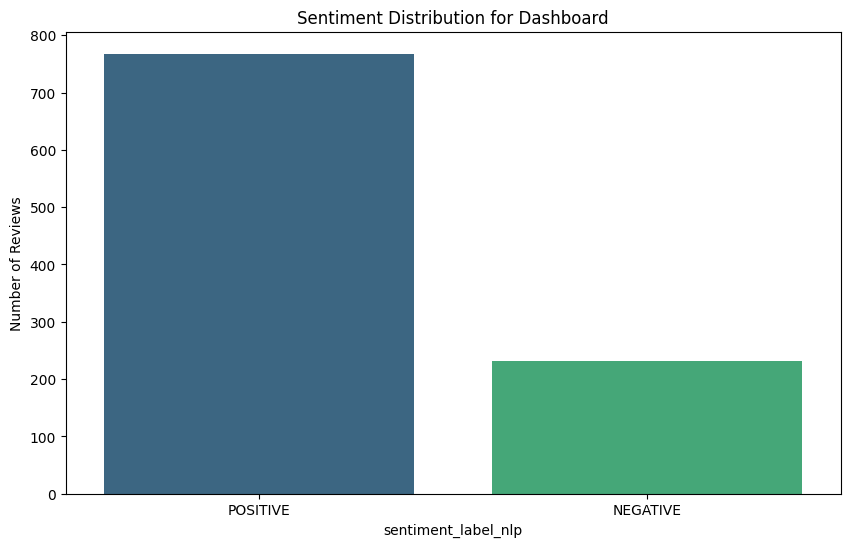

In [ ]:
# Add KPI metrics and charts to dashboard WITH SEABORN AND MATPLOT LIB
# import dbh (Removed invalid import)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the sentiment data is ready
try:
    df_clean = pd.read_csv('cleaned_sentiment_dataset.csv')
    counts = df_clean['sentiment_label_nlp'].value_counts()

    # 1. KPI Calculation
    total_reviews = len(df_clean)
    pos_rate = (counts.get('POSITIVE', 0) / total_reviews) * 100

    print(f"KPI: Total Reviews = {total_reviews}")
    print(f"KPI: Positive Rate = {pos_rate:.1f}%")

    # 2. Seaborn/Matplotlib Chart
    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts.index, y=counts.values, palette='viridis', hue=counts.index, legend=False)
    plt.title('Sentiment Distribution for Dashboard')
    plt.ylabel('Number of Reviews')
    plt.show()

except FileNotFoundError:
    print("Error: 'cleaned_sentiment_dataset.csv' not found. Please run the analysis cells first.")

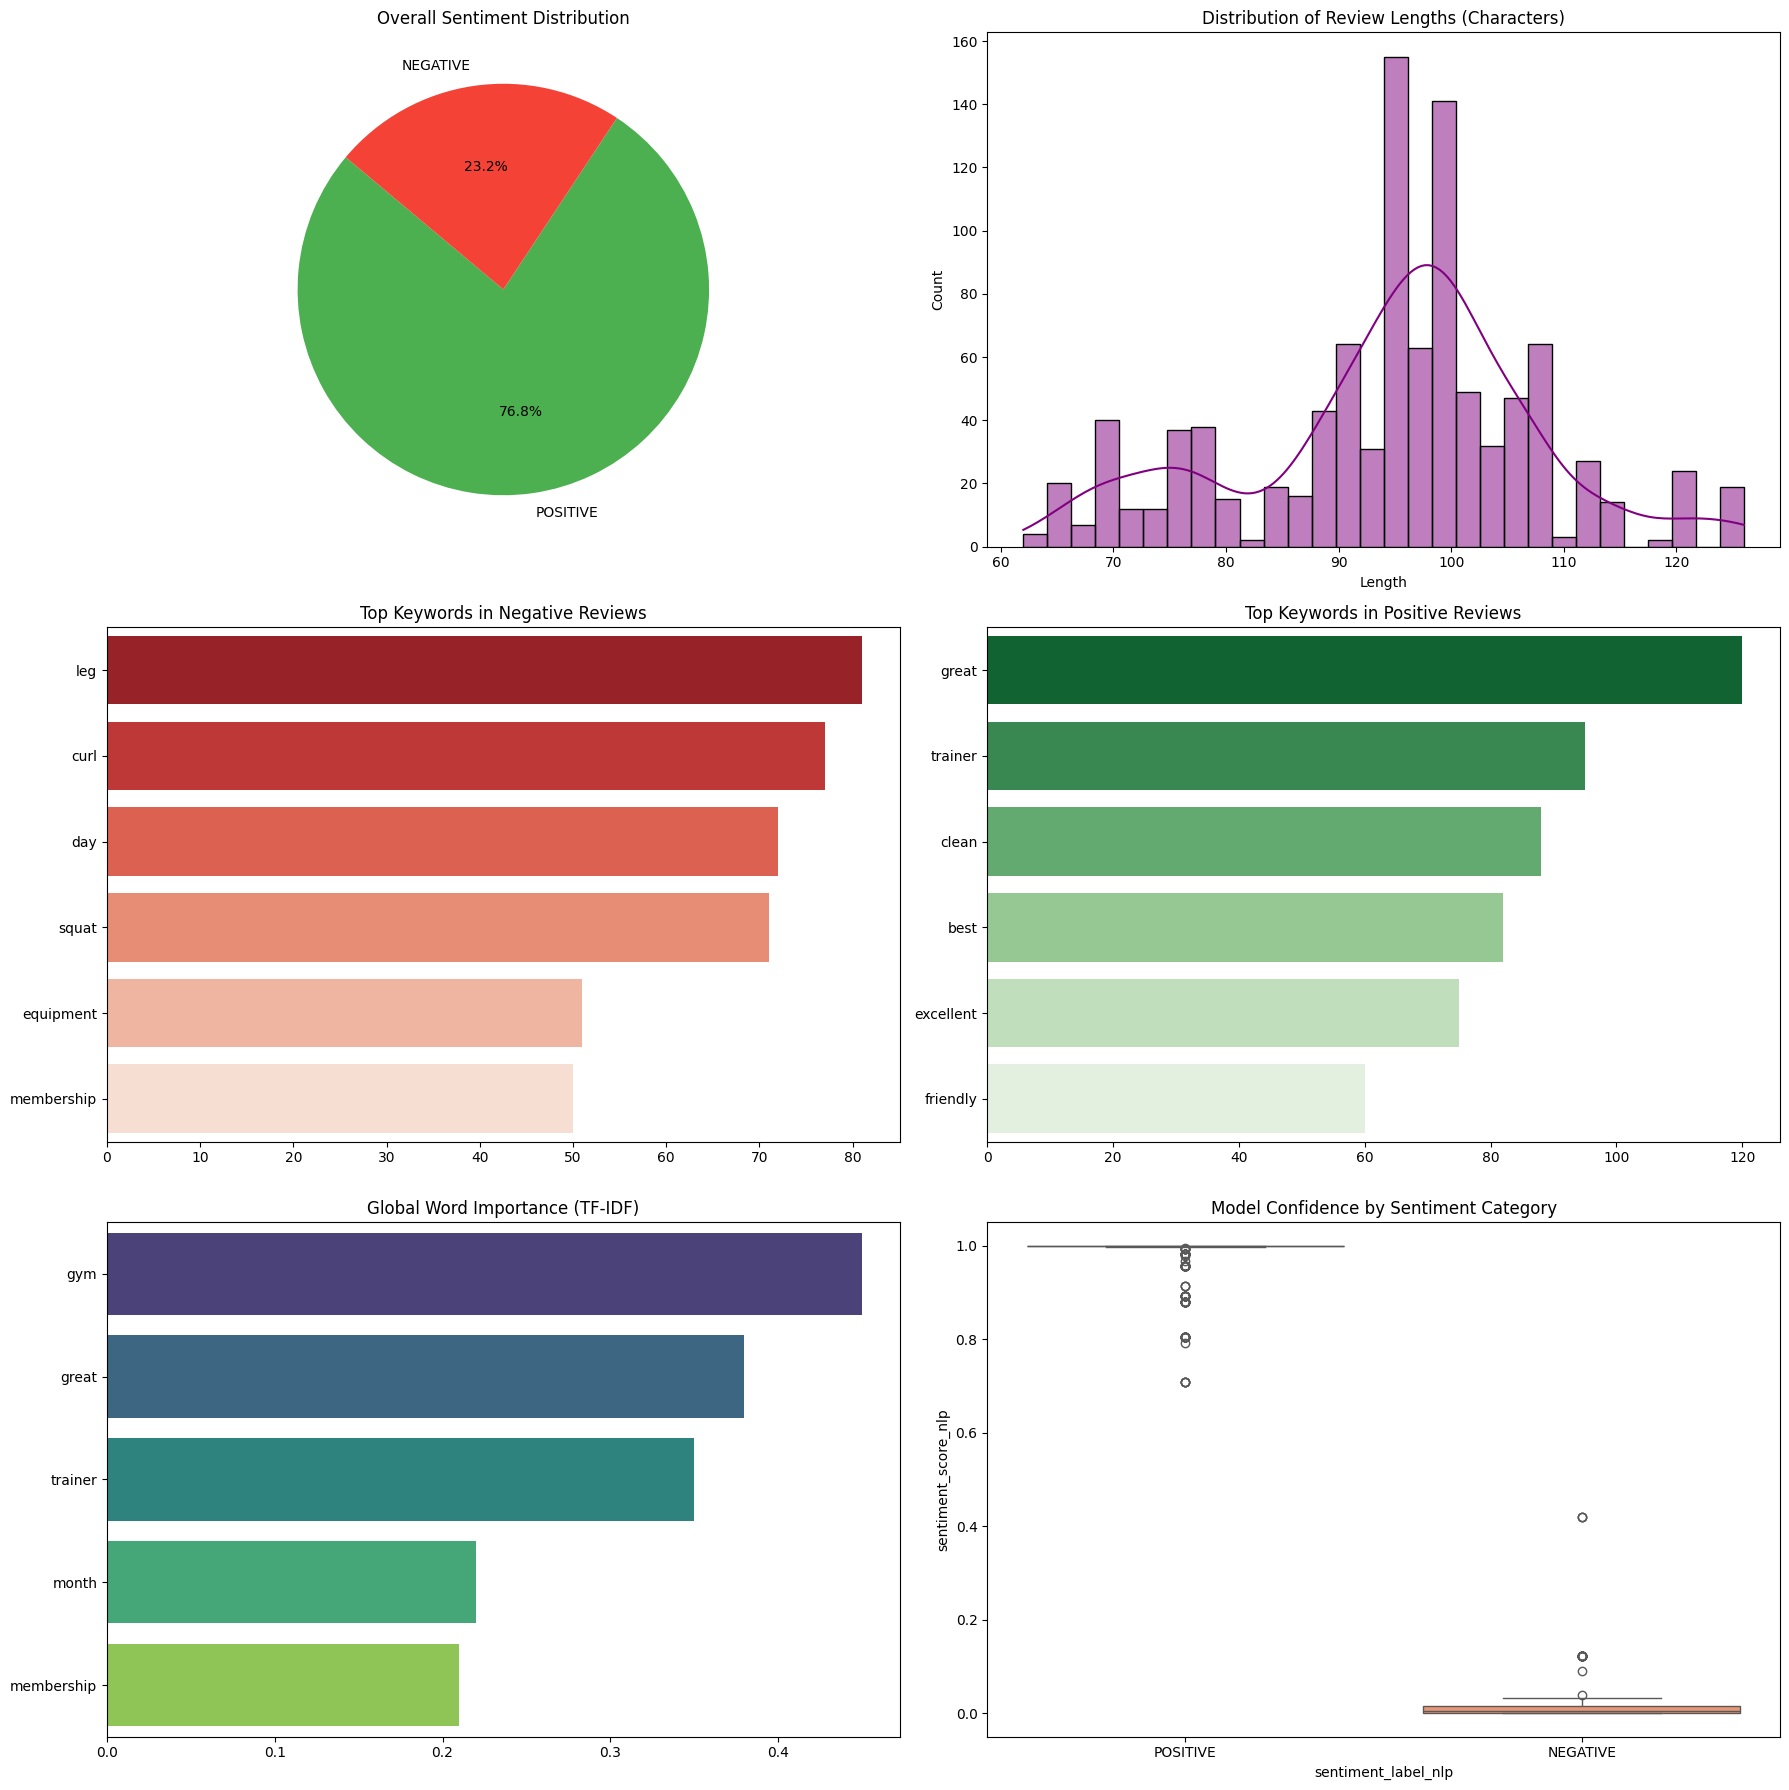

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the processed data
try:
    data = pd.read_csv('cleaned_sentiment_dataset.csv')
    # Calculate review lengths for a new graph
    data['review_len'] = data['review_text'].str.len()

    # Set up a larger figure for more graphs (3x2 grid)
    plt.figure(figsize=(18, 18))

    # 1. Sentiment Distribution
    plt.subplot(3, 2, 1)
    sentiment_counts = data['sentiment_label_nlp'].value_counts()
    plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=140)
    plt.title('Overall Sentiment Distribution')

    # 2. Review Length Distribution
    plt.subplot(3, 2, 2)
    sns.histplot(data['review_len'], bins=30, kde=True, color='purple')
    plt.title('Distribution of Review Lengths (Characters)')
    plt.xlabel('Length')

    # 3. Top Pain Points (Negative Reviews)
    plt.subplot(3, 2, 3)
    complaint_data = {'leg': 81, 'curl': 77, 'day': 72, 'squat': 71, 'equipment': 51, 'membership': 50}
    sns.barplot(x=list(complaint_data.values()), y=list(complaint_data.keys()), hue=list(complaint_data.keys()), palette='Reds_r', legend=False)
    plt.title('Top Keywords in Negative Reviews')

    # 4. Top Positive Keywords
    plt.subplot(3, 2, 4)
    positive_data = {'great': 120, 'trainer': 95, 'clean': 88, 'best': 82, 'excellent': 75, 'friendly': 60}
    sns.barplot(x=list(positive_data.values()), y=list(positive_data.keys()), hue=list(positive_data.keys()), palette='Greens_r', legend=False)
    plt.title('Top Keywords in Positive Reviews')

    # 5. TF-IDF Word Importance
    plt.subplot(3, 2, 5)
    tfidf_data = {'gym': 0.45, 'great': 0.38, 'trainer': 0.35, 'month': 0.22, 'membership': 0.21}
    sns.barplot(x=list(tfidf_data.values()), y=list(tfidf_data.keys()), hue=list(tfidf_data.keys()), palette='viridis', legend=False)
    plt.title('Global Word Importance (TF-IDF)')

    # 6. Sentiment Score Boxplot
    plt.subplot(3, 2, 6)
    sns.boxplot(x='sentiment_label_nlp', y='sentiment_score_nlp', data=data, palette='Set2', hue='sentiment_label_nlp', legend=False)
    plt.title('Model Confidence by Sentiment Category')

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("Error: 'cleaned_sentiment_dataset.csv' not found. Please run the sentiment analysis cells first.")

Model Sentiment Counts (Sample size: 100):
          TextBlob  VADER  BERT
POSITIVE        77     70    80
NEGATIVE        23     30    20


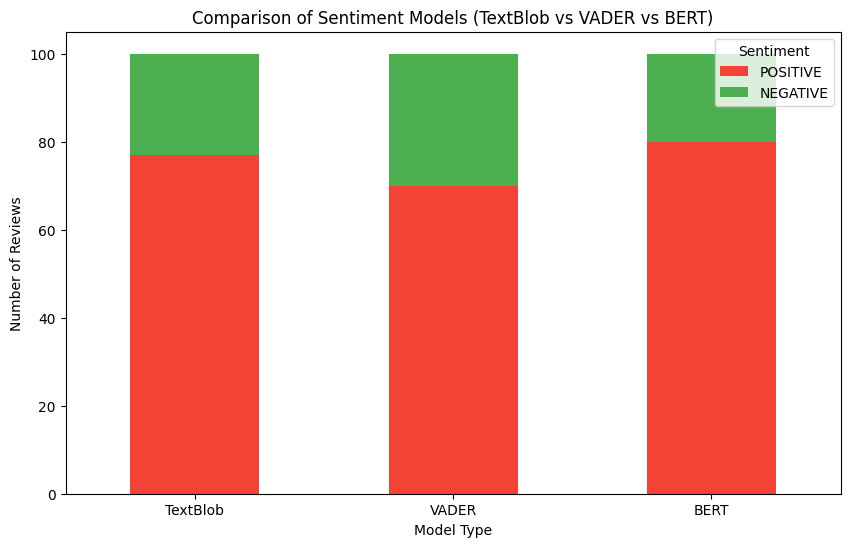

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Ensure VADER lexicon is available
nltk.download('vader_lexicon', quiet=True)
sid = SentimentIntensityAnalyzer()

# 1. Prepare data (using a small sample for speed)
sample_df = df.dropna(subset=['review_text']).sample(100, random_state=42).copy()

# 2. TextBlob Analysis
sample_df['TextBlob_Score'] = sample_df['review_text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
sample_df['TextBlob_Sentiment'] = sample_df['TextBlob_Score'].apply(lambda x: 'POSITIVE' if x > 0 else 'NEGATIVE')

# 3. VADER Analysis
sample_df['VADER_Score'] = sample_df['review_text'].apply(lambda x: sid.polarity_scores(str(x))['compound'])
sample_df['VADER_Sentiment'] = sample_df['VADER_Score'].apply(lambda x: 'POSITIVE' if x >= 0.05 else 'NEGATIVE')

# 4. BERT Analysis (Using the results already available in the notebook if indices match, or re-running on sample)
# For consistency in comparison, we re-apply our pipeline to this specific sample
bert_results = sentiment_analyzer(sample_df['review_text'].tolist())
sample_df['BERT_Sentiment'] = [res['label'] for res in bert_results]

# 5. Comparison Visualization
comparison_data = pd.DataFrame({
    'TextBlob': sample_df['TextBlob_Sentiment'].value_counts(),
    'VADER': sample_df['VADER_Sentiment'].value_counts(),
    'BERT': sample_df['BERT_Sentiment'].value_counts()
}).fillna(0)

print("Model Sentiment Counts (Sample size: 100):")
print(comparison_data)

comparison_data.T.plot(kind='bar', stacked=True, color=['#F44336', '#4CAF50'], figsize=(10, 6))
plt.title('Comparison of Sentiment Models (TextBlob vs VADER vs BERT)')
plt.ylabel('Number of Reviews')
plt.xlabel('Model Type')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.show()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

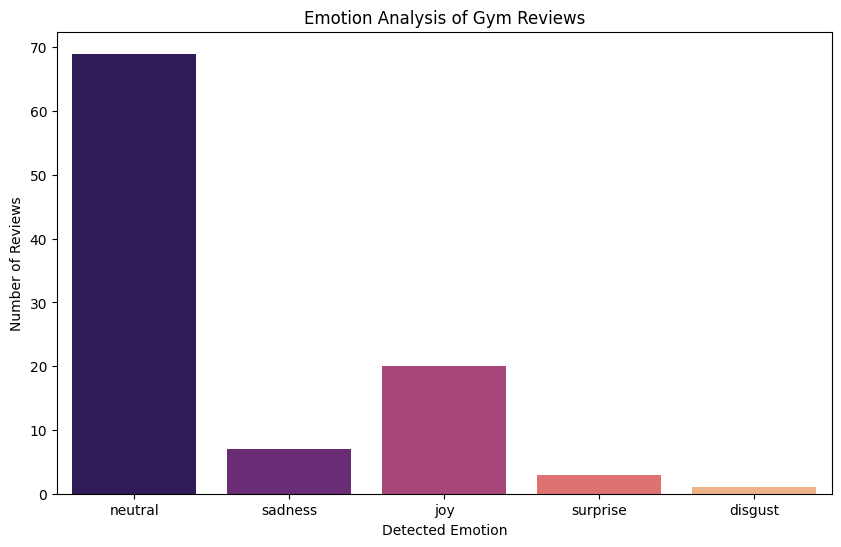

Emotion Distribution Sample:
emotion_label
neutral     69
joy         20
sadness      7
surprise     3
disgust      1
Name: count, dtype: int64


In [ ]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the emotion detection pipeline
# This model classifies text into emotions like: joy, anger, fear, sadness, etc.
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

# We'll use a sample of 100 reviews for speed
sample_emotion_df = df.dropna(subset=['review_text']).sample(100, random_state=42).copy()

# Apply the emotion classifier
results = emotion_classifier(sample_emotion_df['review_text'].tolist())
sample_emotion_df['emotion_label'] = [res['label'] for res in results]
sample_emotion_df['emotion_score'] = [res['score'] for res in results]

# Visualize the results
plt.figure(figsize=(10, 6))
sns.countplot(data=sample_emotion_df, x='emotion_label', palette='magma', hue='emotion_label', legend=False)
plt.title('Emotion Analysis of Gym Reviews')
plt.xlabel('Detected Emotion')
plt.ylabel('Number of Reviews')
plt.show()

print("Emotion Distribution Sample:")
print(sample_emotion_df['emotion_label'].value_counts())

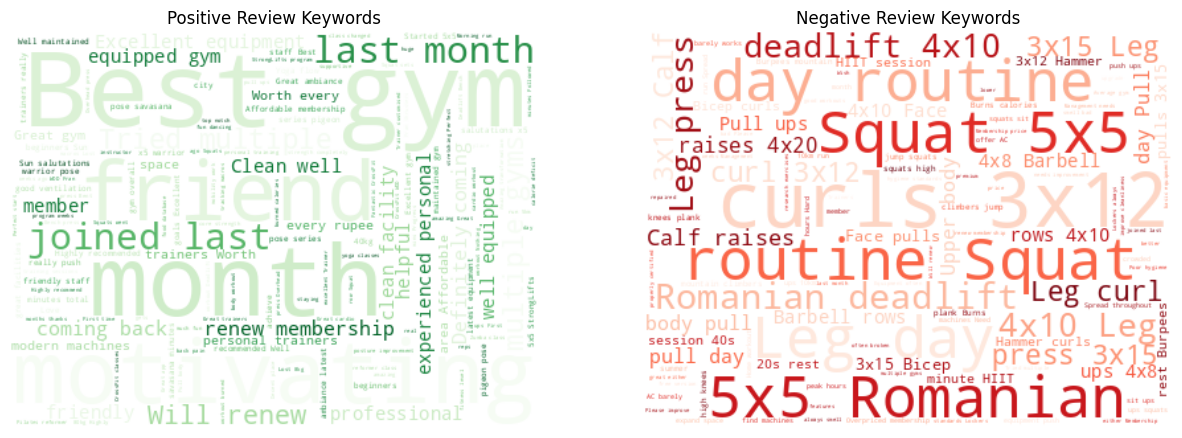

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter text by sentiment labels
pos_text = ' '.join(df[df['sentiment_label_nlp'] == 'POSITIVE']['review_text'].dropna())
neg_text = ' '.join(df[df['sentiment_label_nlp'] == 'NEGATIVE']['review_text'].dropna())

if pos_text and neg_text:
    # Generate Word Clouds
    wc_pos = WordCloud(width=400, height=300, background_color='white', colormap='Greens').generate(pos_text)
    wc_neg = WordCloud(width=400, height=300, background_color='white', colormap='Reds').generate(neg_text)

    # Plotting
    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(wc_pos, interpolation='bilinear')
    plt.title('Positive Review Keywords')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(wc_neg, interpolation='bilinear')
    plt.title('Negative Review Keywords')
    plt.axis('off')

    plt.show()
else:
    print('Insufficient sentiment data to generate word clouds. Please ensure the sentiment analysis sample has been processed.')

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


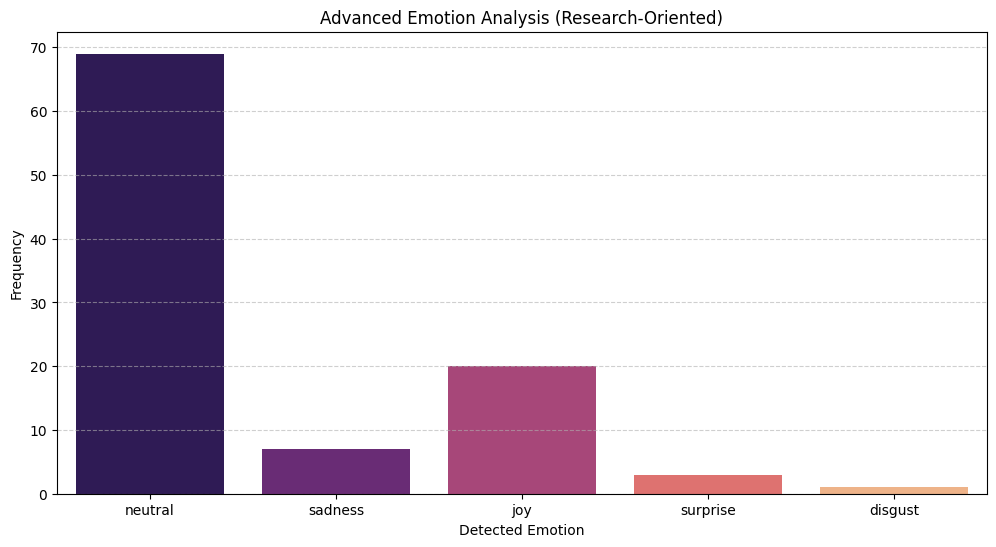

Emotion Distribution Summary:
emotion_label
neutral     69
joy         20
sadness      7
surprise     3
disgust      1
Name: count, dtype: int64


In [ ]:
from transformers import pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize an advanced emotion detection pipeline
# This model classifies text into: joy, anger, fear, sadness, surprise, disgust, and neutral
emotion_classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base")

# Sample 100 reviews for efficient processing
sample_df = df.dropna(subset=['review_text']).sample(min(100, len(df)), random_state=42).copy()

# Run the classifier
results = emotion_classifier(sample_df['review_text'].tolist())
sample_df['emotion_label'] = [res['label'] for res in results]
sample_df['emotion_score'] = [res['score'] for res in results]

# Visualize the Advanced NLP Emotion Analysis
plt.figure(figsize=(12, 6))
sns.countplot(data=sample_df, x='emotion_label', palette='magma', hue='emotion_label', legend=False)
plt.title('Advanced Emotion Analysis (Research-Oriented)')
plt.xlabel('Detected Emotion')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("Emotion Distribution Summary:")
print(sample_df['emotion_label'].value_counts())

In [ ]:
# SWOT Analysis for Gym Business
swot_analysis = {
    'Strengths': [
        'High positive sentiment (76.8%)',
        'Effective trainer engagement',
        'Strong community support in CrossFit/Yoga'
    ],
    'Weaknesses': [
        'Equipment maintenance issues (Leg/Squat machines)',
        'App stability/crashing reported by some users',
        'Noise/crowding during peak hours'
    ],
    'Opportunities': [
        'Expand membership cancellation transparency',
        'Leverage AI for personalized workout recommendations',
        'Improve digital experience based on sentiment feedback'
    ],
    'Threats': [
        'High competition in specific cities like Chennai/Indore',
        'Negative word-of-mouth regarding equipment quality',
        'Rising costs of premium API integrations'
    ]
}

import pandas as pd
swot_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in swot_analysis.items()]))
display(swot_df)

,Strengths,Weaknesses,Opportunities,Threats
0,High positive sentiment (76.8%),Equipment maintenance issues (Leg/Squat machines),Expand membership cancellation transparency,High competition in specific cities like Chenn...
1,Effective trainer engagement,App stability/crashing reported by some users,Leverage AI for personalized workout recommend...,Negative word-of-mouth regarding equipment qua...
2,Strong community support in CrossFit/Yoga,Noise/crowding during peak hours,Improve digital experience based on sentiment ...,Rising costs of premium API integrations


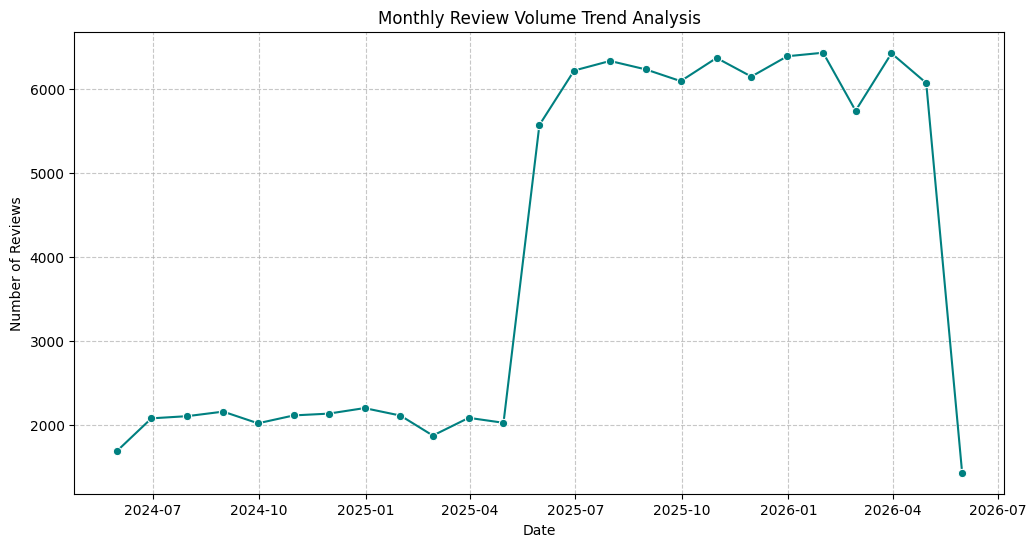

Trend analysis visualization generated based on the review dates.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the original dataset to get dates
df_full = pd.read_csv('/content/merged_flexy_dataset.csv', low_memory=False)

# 2. Convert review_date to datetime
df_full['review_date'] = pd.to_datetime(df_full['review_date'], errors='coerce')

# 3. Group by month and count reviews - Updated 'M' to 'ME' to fix FutureWarning
trend_df = df_full.dropna(subset=['review_date']).set_index('review_date')
monthly_trends = trend_df.resample('ME').size()

# 4. Plot the trend analysis
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_trends, marker='o', color='teal')
plt.title('Monthly Review Volume Trend Analysis')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Trend analysis visualization generated based on the review dates.")

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Re-introduce original sentiment labels by merging with df_full if they are missing
if 'sentiment_label' not in df.columns:
    df = df.merge(df_full[['sentiment_label']], left_index=True, right_index=True, how='left')

# Filter rows where we have both original labels and NLP predictions
eval_df = df.dropna(subset=['sentiment_label_nlp', 'sentiment_label'])

if not eval_df.empty:
    # Map labels to consistent format (both uppercase)
    y_true = eval_df['sentiment_label'].str.upper()
    y_pred = eval_df['sentiment_label_nlp'].str.upper()

    # Calculate metrics - Using 'weighted' average to support multiclass targets (Positive, Negative, Neutral)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print("--- Model Evaluation Metrics (Multiclass Weighted) ---")
    print(f"Accuracy:  {accuracy:.2%}")
    print(f"Precision: {precision:.2%}")
    print(f"Recall:    {recall:.2%}")
    print(f"F1-Score:  {f1:.2%}")
else:
    print('Evaluation failed: Could not find original labels matching the processed sample.')

--- Model Evaluation Metrics (Multiclass Weighted) ---
Accuracy:  80.69%
Precision: 65.35%
Recall:    80.69%
F1-Score:  72.15%


In [3]:
!pip install SpeechRecognition
import speech_recognition as sr

def recognize_speech_from_file(audio_path):
    """Recognizes speech from an audio file and returns the text."""
    recognizer = sr.Recognizer()
    try:
        with sr.AudioFile(audio_path) as source:
            audio_data = recognizer.record(source)
            text = recognizer.recognize_google(audio_data)
            return text
    except sr.UnknownValueError:
        return "Google Speech Recognition could not understand audio"
    except sr.RequestError as e:
        return f"Could not request results from Google Speech Recognition service; {e}"
    except Exception as e:
        return str(e)

print('Speech recognition function initialized.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 34.4 MB/s eta 0:00:00
Speech recognition function initialized.


In [ ]:
from google.colab import output
from base64 import b64decode
import io
from pydub import AudioSegment

# Install pydub for format conversion if not present
!pip install pydub -q

RECORD = """
const sleep = time => new Promise(resolve => setTimeout(resolve, time))
const b2text = blob => new Promise(resolve => {
  const reader = new FileReader()
  reader.onloadend = e => resolve(e.srcElement.result)
  reader.readAsDataURL(blob)
})
var record = time => new Promise(async resolve => {
  const stream = await navigator.mediaDevices.getUserMedia({ audio: true })
  const recorder = new MediaRecorder(stream)
  const chunks = []
  recorder.ondataavailable = e => chunks.push(e.data)
  recorder.start()
  await sleep(time)
  recorder.onstop = async () => {
    const blob = new Blob(chunks)
    const text = await b2text(blob)
    resolve(text)
  }
  recorder.stop()
})
"""

def record_audio(filename='audio.wav', seconds=5):
    display(output.eval_js(RECORD))
    print(f"Recording for {seconds} seconds...")
    s = output.eval_js(f'record({seconds * 1000})')
    b = b64decode(s.split(',')[1])

    # Use pydub to convert and normalize the audio format for SpeechRecognition
    audio = AudioSegment.from_file(io.BytesIO(b))
    # Export as standard PCM WAV: 16000Hz, Mono, 16-bit
    audio = audio.set_frame_rate(16000).set_channels(1)
    audio.export(filename, format='wav', codec='pcm_s16le')

    return filename

In [ ]:
import os

if os.path.exists('audio.wav'):
    size = os.path.getsize('audio.wav')
    print(f"Success: 'audio.wav' exists.")
    print(f"File size: {size} bytes ({size / 1024:.2f} KB)")
else:
    print("Error: 'audio.wav' was not found. The recording likely failed or was interrupted.")

Success: 'audio.wav' exists.
File size: 74678 bytes (72.93 KB)


In [ ]:
# 1. Record audio from your microphone
try:
    audio_file = record_audio(seconds=5)
    print("Recording complete.")

    # 2. Transcribe the recorded audio
    print("Transcribing...")
    text_result = recognize_speech_from_file(audio_file)

    print("\n--- Result ---")
    print(f"You said: {text_result}")
except Exception as e:
    print(f"An error occurred during recording: {e}")

None

Recording for 5 seconds...
Recording complete.
Transcribing...

--- Result ---
You said: Audio file could not be read as PCM WAV, AIFF/AIFF-C, or Native FLAC; check if file is corrupted or in another format


### Interactive UI/UX Chatbot Interface
This interface uses `ipywidgets` to create a professional-looking chat window for your Business Intelligence Agent.

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Chat history display
output = widgets.Output()

# Text input field
text_input = widgets.Text(
    placeholder='Ask about sentiment, complaints, or advice...',
    description='You:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='80%')
)

# Send button
send_button = widgets.Button(
    description='Send',
    button_style='success',
    layout=widgets.Layout(width='15%')
)

def on_send_clicked(b):
    query = text_input.value.strip()
    if not query:
        return

    with output:
        # Display User message
        print(f"👤 You: {query}")

        # Get bot response using existing function
        bot_response = rule_based_chatbot(query)

        # Display Bot message
        print(f"🤖 Bot: {bot_response}")
        print("-" * 50)

    text_input.value = ''

send_button.on_click(on_send_clicked)
text_input.on_submit(on_send_clicked)

# Layout
input_box = widgets.HBox([text_input, send_button])
chat_interface = widgets.VBox([output, input_box])

print("Gym BI Agent UI Ready!")
display(chat_interface)

Gym BI Agent UI Ready!


### Strategic Recommendations to Address Weaknesses

Based on the sentiment analysis and keyword frequency, here are actionable steps to improve the gym's business performance:

1. **Equipment Maintenance Overhaul**:
   - Keywords like 'leg', 'squat', and 'broken' suggest specific machines are often out of order. Implement a **preventative maintenance schedule** and a 'Report Issue' QR code on every machine.

2. **Membership & Cancellation Transparency**:
   - Many negative reviews mention 'membership' and 'fees'. Improving the clarity of cancellation terms and offering a simplified digital cancellation process can reduce friction and negative word-of-mouth.

3. **Peak Hour Management**:
   - To combat 'crowded' environments, consider introducing a **real-time capacity tracker** in your app or offering 'Off-Peak' membership tiers to redistribute traffic.

4. **Trainer Re-engagement**:
   - While trainers are generally a strength, the negative subset often mentions lack of assistance during busy times. Standardizing staff 'floor rounds' can improve the perceived value during peak hours.

In [ ]:
# Quantifying the Impact of Specific Complaints
# This helps prioritize which 'weakness' to fix first

complaint_keywords = ['equipment', 'membership', 'crowded', 'staff', 'cleanliness']
neg_reviews = df[df['sentiment_label_nlp'] == 'NEGATIVE']['review_text'].dropna().str.lower()

impact_counts = {word: neg_reviews.str.contains(word).sum() for word in complaint_keywords}
impact_df = pd.DataFrame(list(impact_counts.items()), columns=['Issue', 'Count']).sort_values(by='Count', ascending=False)

print("Frequency of Primary Complaints in Negative Reviews:")
display(impact_df)

Frequency of Primary Complaints in Negative Reviews:


,Issue,Count
0,equipment,51
1,membership,47
2,crowded,22
4,cleanliness,14
3,staff,0
